## Моделирование O₂–O₂ (Ahn & Adamovich)

Stimulated Raman scattering measurements of V–V transfer in oxygen — Tai Ahn, Igor Adamovich, Walter R. Lempert

In [1]:
import matplotlib.pyplot as plt

from particles import O2
from k_VV import k_vv_fhofer


In [30]:
from pathlib import Path

from vv_modeling import ModelingConfig, ModelingBatch, k_lookup
from experiments import get_experiment

batch = ModelingBatch([
    ModelingConfig(
        name="FHO-FR reg",
        base_dir=Path("."),
        particle_a="O2",
        particle_b="O2",
        kinetics="regression",
        fortran_scale=1.0,
        rate_multiplier=1.0,
        rate_multipliers={"solid": 1.0, "dashed": 8.0},

        # физика
        T=300.0,
        v_max=6,
        n_total=5.07e18,
        f_v0=0.63,
        f_v1=0.37,

        # интегрирование
        t_end_s=12e-6,
        n_time=600,

        # диффузия
        diffusion_method="method_of_lines",
        sigma_pump_cm=80e-4,
        sigma_probe_cm=40e-4,
        d_ref=0.2,
        p_torr=760.0,

        # сетка method of lines
        r_max_cm=200e-4,
        n_r=80,

        # эксперимент: inline Ahn + v{v}solid/dashed.csv
        experiment_key=("O2", "O2", 760),
    ),
    ModelingConfig(
        name="FHO-FR reg",
        base_dir=Path("."),
        particle_a="O2",
        particle_b="O2",
        kinetics="fhofer",
        fortran_scale=1.0,
        rate_multiplier=1.0,
        rate_multipliers={"solid": 1.0, "dashed": 8.0},

        # физика
        T=300.0,
        v_max=6,
        n_total=5.07e18,
        f_v0=0.63,
        f_v1=0.37,

        # интегрирование
        t_end_s=12e-6,
        n_time=600,

        # диффузия
        diffusion_method="analytic_factor",
        sigma_pump_cm=80e-4,
        sigma_probe_cm=40e-4,
        d_ref=0.2,
        p_torr=760.0,

        # сетка method of lines
        r_max_cm=200e-4,
        n_r=80,

        # эксперимент: inline Ahn + v{v}solid/dashed.csv
        experiment_key=("O2", "O2", 760),
    )
])

batch.run_all(max_workers=10)
from vv_plotting import completed_run_labels

print("done:", ", ".join(completed_run_labels(batch)))


k_VV: O2_O2_regression_coefs.csv (72 переходов)
k_VV: O2_O2_regression_coefs.csv (72 переходов)
Предупреждение: v6solid.csv не найден
Предупреждение: v6dashed.csv не найден
Предупреждение: fho760v6.csv не найден
  готово: FHO-FR reg::analytic_factor
Предупреждение: v6solid.csv не найден
Предупреждение: v6dashed.csv не найден
Предупреждение: fho760v6.csv не найден
  готово: FHO-FR reg::method_of_lines
done: FHO-FR reg (метод прямых), FHO-FR reg (аналит. фактор)


На графике: FHO-FR reg (метод прямых), FHO-FR reg (аналит. фактор)


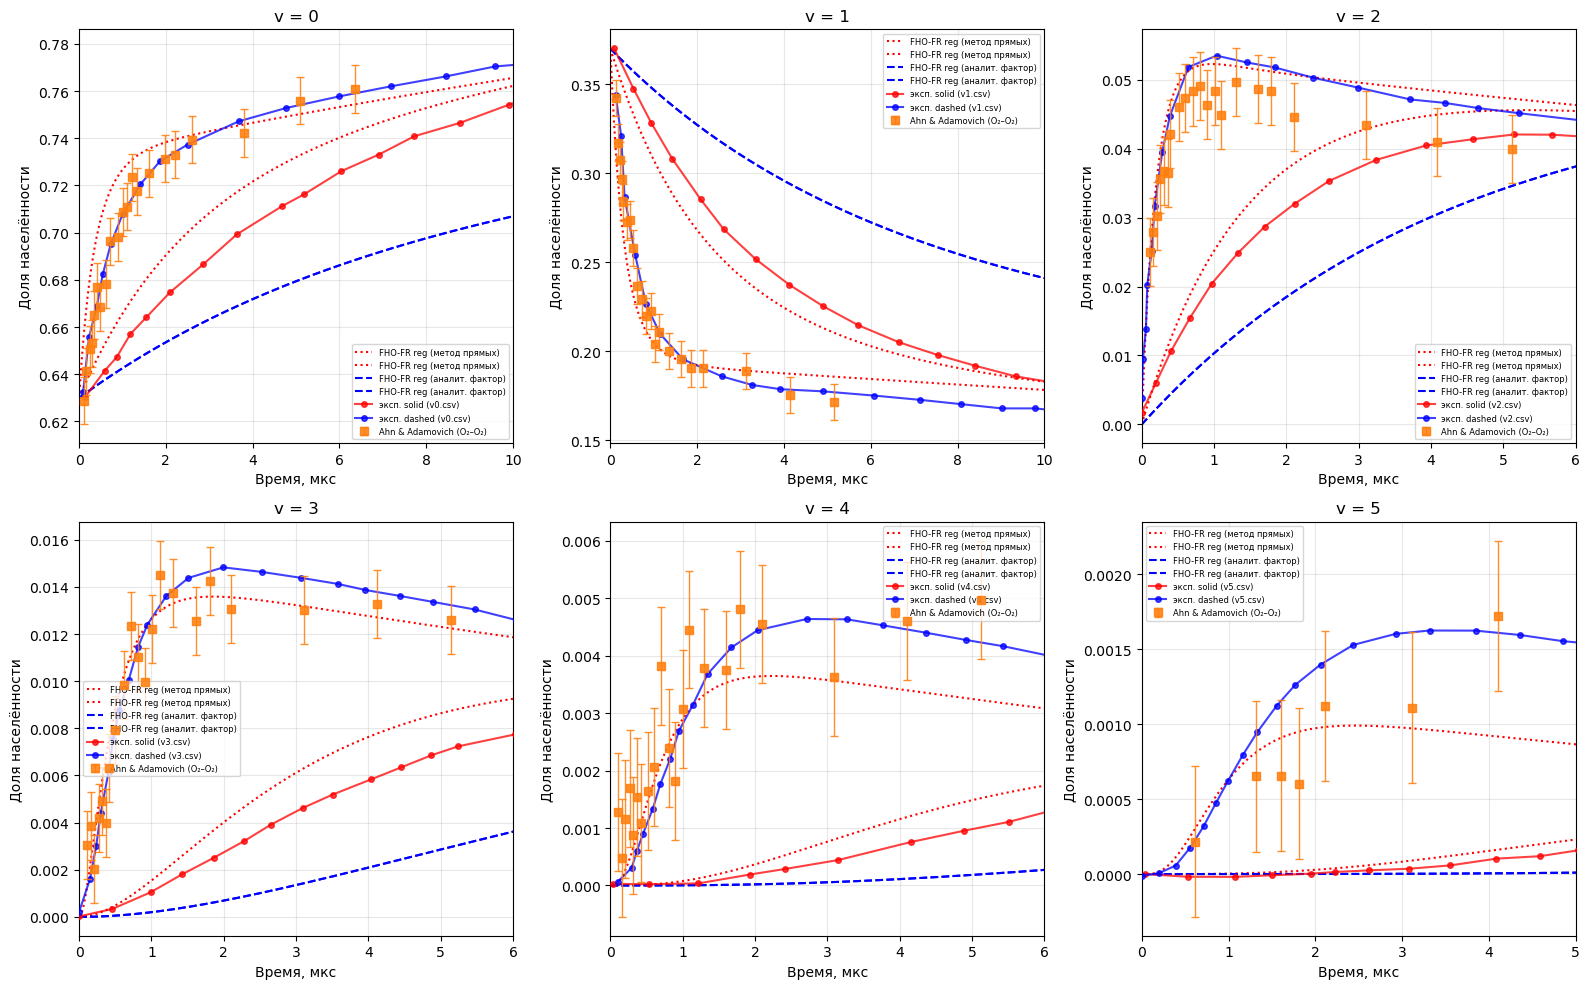

In [31]:
from vv_plotting import (
    PopulationPlotConfig,
    plot_population_grid,
    print_population_summaries,
    completed_run_labels,
)

# Макс. время по оси X (мкс) для каждого v=0…5
PLOT = PopulationPlotConfig(
    diffusion_per_run=True,
    plot_styles={"solid": {"color": "red"}, "dashed": {"color": "blue"}},
    exp_csv_colors={"solid": "red", "dashed": "blue"},
    legend_exp_dots="Ahn & Adamovich (O₂–O₂)",
    show_article_fho=False,
    max_v_plots=6,
    t_max_us_by_v=(10, 10, 6, 6, 6, 5),
)

PLOT_RUNS = None
print("На графике:", ", ".join(completed_run_labels(batch, PLOT_RUNS)))

fig, axes = plot_population_grid(batch, runs=PLOT_RUNS, plot_cfg=PLOT)
plt.show()

Данные: `batch.run_at(0).exp_data` — ключи `dots`, `solid`, `dashed`.

## Сравнение k_VV FHO-FR из статьи с k_vv_mm


In [ ]:
import os
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

from k_VV import k_vv_mm_for_v
from experiments import get_experiment

_o2_exp = get_experiment("O2", "O2", 760)
x_FHO_FR_VV_O2_exp_art, y_FHO_FR_VV_O2_exp_art = _o2_exp["k_vv_article"]
    0.9938208032955717, 1.8949536560247169, 2.981462409886715, 3.98043254376931, 5,
    5.988671472708548, 6.9876416065911435, 7.981462409886715, 8.98043254376931, 9.974253347064883,
]
    1.774128673481946e-14, 3.2878708489951796e-14, 4.271514327281122e-14, 4.646412110697944e-14,
    4.588862098611196e-14, 4.153395113650955e-14, 3.576437244658811e-14, 2.911660472634801e-14,
    2.3410901225667054e-14, 1.7907899768128867e-14,
]

T_O2_VV_plot = 300
v_int = np.arange(1, len(y_FHO_FR_VV_O2_exp_art) + 1)
_worker = partial(k_vv_mm_for_v, 'O2', 'O2', T=T_O2_VV_plot)
max_workers = min(len(v_int), os.cpu_count() or 8)
with ProcessPoolExecutor(max_workers=max_workers) as ex:
    k_from_mm = list(ex.map(_worker, v_int, chunksize=1))


In [ ]:
_run = batch.run_at(0)
coeffs = _run.config.coeffs
fortran_scale = 1e6
T_vv = _run.config.T

k_vv_fortran_O2 = np.array([
    k_vv_fhofer(O2, O2, i1=v - 1, f1=v, i2=0, f2=1, T=T_vv) for v in range(1, 11)
])
k_reg_O2 = np.array([
    k_lookup(coeffs, i1=v - 1, f1=v, i2=0, f2=1, T=T_vv) for v in range(1, 7)
])

k_mm_plot = np.where(k_from_mm > 0, k_from_mm, np.nan)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(x_FHO_FR_VV_O2_exp_art, y_FHO_FR_VV_O2_exp_art, "s-", ms=7, label="статья (O₂–O₂)")
ax.plot(v_int, k_mm_plot, "o-", ms=6, label=f"k_vv_mm, T = {T_O2_VV_plot} K")
ax.plot(v_int, k_vv_fortran_O2 * fortran_scale, "o-", label=f"FHO-FR × {fortran_scale:g}")
ax.plot(range(1, 7), k_reg_O2, "^-", ms=6, label="регрессия k_VV")
ax.set_yscale("log")
ax.set_ylim(1e-14, 1e-12)
ax.set_xlabel(r"$v$ ($i_1=v$, $f_1=v-1$, $i_2=0$, $f_2=1$)")
ax.set_ylabel(r"$k_{\mathrm{VV}}$ (см³/с)")
ax.set_title("O₂–O₂ V–V: статья vs k_vv_mm")
ax.grid(True, which="both", linestyle="--", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()
